# Healthletics: AI-Powered Member Retention and Churn Prediction System

## Capstone Project

### Introduction

Healthletics is a fitness and wellness business that provides training and fitness services to its members. As the business grows, there is an opportunity to use data and artificial intelligence to better understand member behavior and improve member retention.

This capstone project focuses on predicting gym member churn, or the likelihood that a member will stop renewing their membership. Member retention is important because identifying members who may be at risk of leaving can allow the business to take action before the member actually churns.

The project uses a public gym membership dataset as a proof of concept. The dataset contains information related to membership characteristics, member demographics, attendance and activity behavior, and churn outcomes.

The objective is to develop and evaluate machine learning models that can identify patterns associated with member churn and predict members who may be at higher risk of leaving.

The results of this project can serve as a foundation for a future Healthletics member management and analytics system, where real Healthletics data could eventually be used to support data-driven retention strategies.

# Step 1 — Problem Understanding & Framing

## 1.1 Business Problem

Healthletics needs a way to identify members who may be at risk of leaving or not renewing their membership. By identifying potential churn risks early, the business can take timely retention actions and better understand the factors associated with member retention.

The goal is to move from a reactive approach, where action is taken after a member leaves, toward a more proactive, data-driven retention strategy.

## 1.2 Data Science Problem

Can machine learning use gym membership, demographic, and member activity data to predict whether a gym member is likely to churn?

The project will analyze member characteristics and behavioral patterns to identify factors associated with churn and develop a model that can classify members according to their likelihood of churning.

## 1.3 Machine Learning Task

This is a **supervised learning — binary classification** problem.

The model will predict one of two outcomes:

- **0 — Retained:** member does not churn
- **1 — Churned:** member churns or does not renew

The target variable is **Churn**.

## 1.4 Proposed Features

The analysis will consider available variables related to:

- Membership and contract characteristics
- Member demographics
- Gym participation and activity
- Class attendance/frequency
- Membership lifetime
- Additional spending and engagement indicators

Feature engineering will also be performed where appropriate to create variables that may better represent changes in member behavior.

## 1.5 Model Success Metrics

The primary machine learning evaluation metric will be **ROC-AUC**, supported by:

- Recall
- Precision
- F1-score
- Accuracy

ROC-AUC is selected as the primary metric because the project is focused on distinguishing members who are likely to churn from those who are likely to remain, rather than relying on accuracy alone.

## 1.6 Business KPIs

The main business KPI will be **Member Retention Rate**.

Supporting KPIs include:

- Churn Rate
- Renewal Rate
- Number of at-risk members identified
- Retention of previously at-risk members
- Average member attendance
- Member engagement
- Potential revenue retained

## 1.7 Project Objective

The objective of this capstone is to develop a machine learning proof of concept that can identify members at higher risk of churn and provide insights that can support proactive member retention strategies at Healthletics.

# Step 2 — Data Collection & Understanding

## 2.1 Dataset Overview

The dataset used for this project is the **Gym Customers Features and Churn** dataset. It contains information about gym members, including membership characteristics, demographic information, participation behavior, and churn outcomes.

The dataset is used as a public-data proof of concept for the Healthletics member retention problem.

The dataset will first be inspected to understand its structure, variables, data types, data quality, and target variable before proceeding to preprocessing and exploratory data analysis.

In [ ]:
import pandas as pd

# Load the Healthletics gym churn dataset
df = pd.read_csv("/content/gym_churn_us.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 4000
Columns: 14


In [ ]:
# Display the first 5 rows of the dataset
df.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [ ]:
# Display all column names
print("Columns in the dataset:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the dataset:
1. gender
2. Near_Location
3. Partner
4. Promo_friends
5. Phone
6. Contract_period
7. Group_visits
8. Age
9. Avg_additional_charges_total
10. Month_to_end_contract
11. Lifetime
12. Avg_class_frequency_total
13. Avg_class_frequency_current_month
14. Churn


In [ ]:
# Check the data types of all columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [ ]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# Summary statistics for the dataset
df.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [ ]:
# Check the distribution of the target variable
churn_counts = df["Churn"].value_counts().sort_index()

print("Churn distribution:")
print(churn_counts)

print("\nChurn percentage:")
print((df["Churn"].value_counts(normalize=True).sort_index() * 100).round(2))

Churn distribution:
Churn
0    2939
1    1061
Name: count, dtype: int64

Churn percentage:
Churn
0    73.47
1    26.52
Name: proportion, dtype: float64


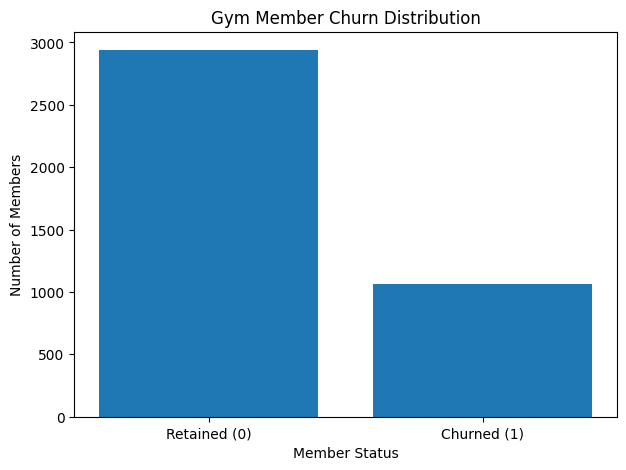

In [ ]:
import matplotlib.pyplot as plt

# Visualize the churn distribution
churn_counts = df["Churn"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["Retained (0)", "Churned (1)"], churn_counts.values)

plt.title("Gym Member Churn Distribution")
plt.xlabel("Member Status")
plt.ylabel("Number of Members")

plt.show()

### Interpretation

The dataset contains 4,000 gym-member records. Of these, 2,939 members (73.47%) are classified as retained, while 1,061 members (26.52%) are classified as churned.

The distribution shows that retained members represent the larger group, while churned members account for approximately one-quarter of the dataset. This indicates some class imbalance in the target variable, which will be considered when selecting and evaluating machine learning models.

Because identifying members who may churn is an important business objective, model evaluation will not rely on accuracy alone. Recall, precision, F1-score, and ROC-AUC will also be considered.

## 2.2 Data Dictionary

| Variable | Type | Description |
|---|---|---|
| `gender` | Binary | Gender indicator recorded as 0 or 1 in the dataset |
| `Near_Location` | Binary | Indicates whether the member lives near the gym |
| `Partner` | Binary | Indicates whether the member is associated with a partner organization |
| `Promo_friends` | Binary | Indicates whether the member joined through a friend promotion |
| `Phone` | Binary | Indicates whether a phone number was provided |
| `Contract_period` | Numerical | Membership contract duration in months |
| `Group_visits` | Binary | Indicates participation in group visits |
| `Age` | Numerical | Member age |
| `Avg_additional_charges_total` | Numerical | Total average additional charges associated with the member |
| `Month_to_end_contract` | Numerical | Number of months remaining until the membership contract ends |
| `Lifetime` | Numerical | Length of the member's relationship with the gym |
| `Avg_class_frequency_total` | Numerical | Average class attendance frequency over the member's overall membership period |
| `Avg_class_frequency_current_month` | Numerical | Average class attendance frequency during the current month |
| `Churn` | Binary target | Target variable: 0 = retained and 1 = churned |

### Target Variable

The target variable for this project is **`Churn`**. It is a binary classification target where 0 represents retained members and 1 represents churned members.

## 2.3 Feature Types and Initial Observations

The dataset contains two main types of predictor variables:

- **Binary variables:** gender, Near_Location, Partner, Promo_friends, Phone, and Group_visits
- **Numerical variables:** Contract_period, Age, Avg_additional_charges_total, Month_to_end_contract, Lifetime, Avg_class_frequency_total, and Avg_class_frequency_current_month

The target variable, `Churn`, is binary, with 0 representing retained members and 1 representing churned members.

Initial inspection shows that the dataset is structurally clean, with no missing values and no duplicate records. The target variable is moderately imbalanced because retained members represent approximately 73% of the observations while churned members represent approximately 27%.

The numerical variables will be examined further during exploratory data analysis to identify differences between retained and churned members, potential outliers, relationships between variables, and behavioral patterns that may help predict churn.


# Step 3 — Data Preprocessing, Applied EDA & Feature Engineering

## 3.1 Data Quality and Cleaning

Before applying machine learning models, the dataset will be checked for missing values, duplicate records, inconsistent data types, and potential outliers.

The initial inspection found no missing values and no duplicate records. Further exploratory analysis will be used to determine whether numerical variables contain unusual observations that require investigation.

The objective is to preserve valid member observations while preparing the dataset for reliable exploratory analysis and subsequent machine learning.

In [ ]:

# Check for missing values and duplicate rows

missing_values = df.isnull().sum()
duplicate_count = df.duplicated().sum()

print("Missing values by column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())
print("Duplicate rows:", duplicate_count)

Missing values by column:
gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

Total missing values: 0
Duplicate rows: 0


In [ ]:
# Check numerical variables for unusual values

numerical_columns = [
    "Contract_period",
    "Age",
    "Avg_additional_charges_total",
    "Month_to_end_contract",
    "Lifetime",
    "Avg_class_frequency_total",
    "Avg_class_frequency_current_month"
]

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
Age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
Avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
Month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000
Lifetime,4000.0,3.724750,3.749267,0.000000,1.000000,3.000000,5.000000,31.000000
Avg_class_frequency_total,4000.0,1.879020,0.972245,0.000000,1.180875,1.832768,2.536078,6.023668
Avg_class_frequency_current_month,4000.0,1.767052,1.052906,0.000000,0.963003,1.719574,2.510336,6.146783


In [ ]:
# Identify potential outliers using the IQR method

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"{column}: {len(outliers)} potential outliers")

Contract_period: 0 potential outliers
Age: 32 potential outliers
Avg_additional_charges_total: 29 potential outliers
Month_to_end_contract: 0 potential outliers
Lifetime: 192 potential outliers
Avg_class_frequency_total: 16 potential outliers
Avg_class_frequency_current_month: 8 potential outliers


### Outlier Assessment

The IQR method identified potential outliers in Age, Avg_additional_charges_total, Lifetime, Avg_class_frequency_total, and Avg_class_frequency_current_month.

These observations were not automatically removed because a statistical outlier is not necessarily an invalid observation. In a gym membership context, higher lifetime, spending, or attendance values may represent legitimate long-term or highly engaged members.

The potential outliers will therefore be retained. Their impact will be considered during exploratory analysis and machine learning, with appropriate preprocessing applied where required.

## 3.2 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand patterns and relationships in the dataset before building machine learning models.

The analysis will compare retained and churned members across membership characteristics, demographics, and engagement-related variables.

The main objectives are to identify:
- Differences between retained and churned members
- Membership factors associated with churn
- Engagement and attendance patterns
- Relationships between predictor variables
- Potential features that may be useful for churn prediction

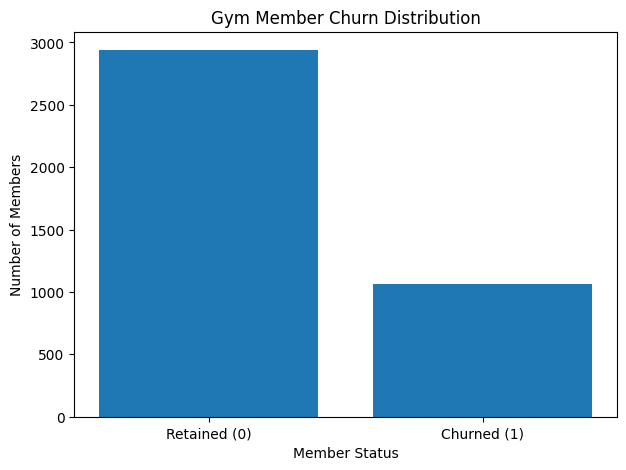

In [ ]:
# EDA 1: Churn distribution

churn_counts = df["Churn"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["Retained (0)", "Churned (1)"], churn_counts.values)

plt.title("Gym Member Churn Distribution")
plt.xlabel("Member Status")
plt.ylabel("Number of Members")

plt.show()

### EDA 1 Interpretation — Churn Distribution

The dataset contains 4,000 gym-member records. A total of 2,939 members (73.47%) are classified as retained, while 1,061 members (26.52%) are classified as churned.

The churned group represents approximately one-quarter of the dataset. This indicates some class imbalance in the target variable, which should be considered when training and evaluating the machine learning models.

Because the business objective is to identify members who may be at risk of churn, model evaluation should consider recall, precision, F1-score, and ROC-AUC rather than relying on accuracy alone.

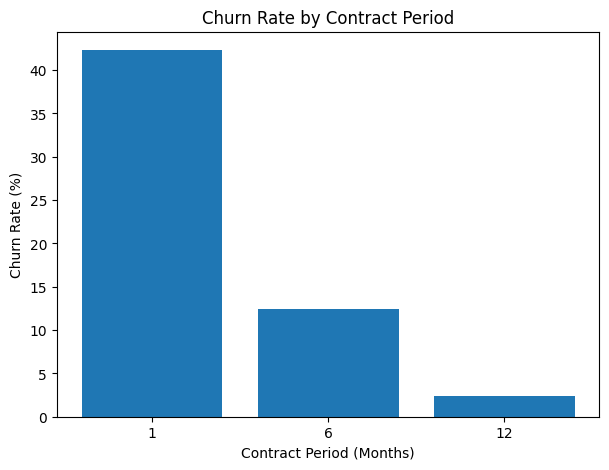

Churn rate by contract period:
Contract_period
1     42.32
6     12.48
12     2.40
Name: Churn, dtype: float64


In [ ]:
# EDA 2: Churn rate by contract period

contract_churn = df.groupby("Contract_period")["Churn"].mean() * 100

plt.figure(figsize=(7, 5))
plt.bar(
    contract_churn.index.astype(str),
    contract_churn.values
)

plt.title("Churn Rate by Contract Period")
plt.xlabel("Contract Period (Months)")
plt.ylabel("Churn Rate (%)")
plt.show()

print("Churn rate by contract period:")
print(contract_churn.round(2))

### EDA 2 Interpretation — Churn Rate by Contract Period

The analysis shows a clear relationship between membership contract duration and churn. Members with 1-month contracts have the highest churn rate at approximately 42.38%. This decreases substantially to 12.48% for members with 6-month contracts and to only 2.40% for members with 12-month contracts.

This suggests that members with shorter contract commitments may be more likely to discontinue their membership. Contract period may therefore be an important predictor of churn and should be considered during feature selection and model development.

From a business perspective, this finding may indicate an opportunity for Healthletics to improve retention among short-term members through stronger onboarding, engagement programs, renewal reminders, or appropriate longer-term membership offers.

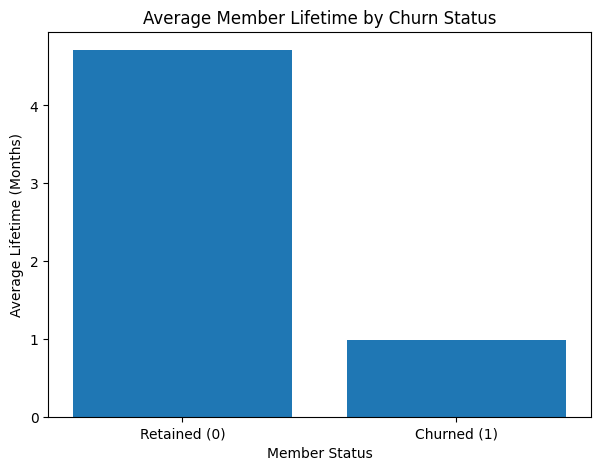

Average lifetime by churn status:
Churn
0    4.71
1    0.99
Name: Lifetime, dtype: float64


In [ ]:
# EDA 3: Member lifetime vs. churn

lifetime_churn = df.groupby("Churn")["Lifetime"].mean()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Retained (0)", "Churned (1)"],
    lifetime_churn.values
)

plt.title("Average Member Lifetime by Churn Status")
plt.xlabel("Member Status")
plt.ylabel("Average Lifetime (Months)")
plt.show()

print("Average lifetime by churn status:")
print(lifetime_churn.round(2))

### EDA 3 Interpretation — Member Lifetime and Churn

The analysis shows a substantial difference in average member lifetime between retained and churned members. Retained members have an average lifetime of approximately 4.71 months, while churned members have an average lifetime of only 0.99 months.

This suggests that newer members may be at greater risk of churn, while members who remain engaged with the gym for a longer period are more likely to be retained. Lifetime is therefore an important candidate feature for predicting member churn.

From a business perspective, this finding highlights the importance of the early membership period. Healthletics could focus on stronger onboarding, early engagement, and follow-up activities to help new members develop consistent gym participation and remain active.

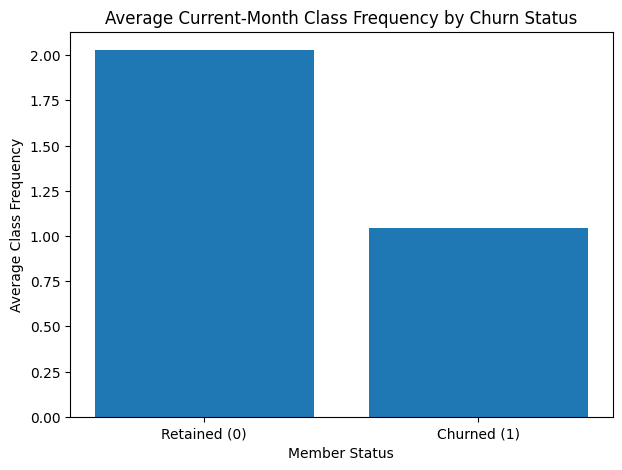

Average current-month class frequency by churn status:
Churn
0    2.03
1    1.04
Name: Avg_class_frequency_current_month, dtype: float64


In [ ]:
# EDA 4: Average class attendance frequency by churn status

frequency_churn = df.groupby("Churn")[
    "Avg_class_frequency_current_month"
].mean()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Retained (0)", "Churned (1)"],
    frequency_churn.values
)

plt.title("Average Current-Month Class Frequency by Churn Status")
plt.xlabel("Member Status")
plt.ylabel("Average Class Frequency")
plt.show()

print("Average current-month class frequency by churn status:")
print(frequency_churn.round(2))

### EDA 4 Interpretation — Attendance Frequency and Churn

The analysis shows a clear difference in current-month class attendance between retained and churned members. Retained members have an average current-month class frequency of approximately 2.03, while churned members have an average of only 1.04.

This indicates that lower recent participation is associated with a higher likelihood of churn. Current-month attendance frequency is therefore an important candidate feature for predicting member churn.

From a business perspective, recent attendance can serve as an early engagement signal. Healthletics could use declining attendance as an indicator to identify members who may need follow-up, encouragement, or targeted engagement before they decide not to renew.

In [ ]:
import matplotlib.pyplot as plt

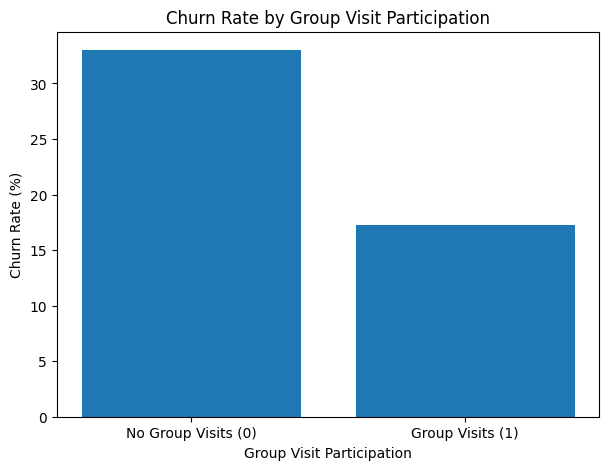

Churn rate by group visit participation:
Group_visits
0    33.01
1    17.28
Name: Churn, dtype: float64


In [ ]:
# EDA 5: Group visits and churn

group_visit_churn = df.groupby("Group_visits")["Churn"].mean() * 100

plt.figure(figsize=(7, 5))
plt.bar(
    ["No Group Visits (0)", "Group Visits (1)"],
    group_visit_churn.values
)

plt.title("Churn Rate by Group Visit Participation")
plt.xlabel("Group Visit Participation")
plt.ylabel("Churn Rate (%)")
plt.show()

print("Churn rate by group visit participation:")
print(group_visit_churn.round(2))

### EDA 5 Interpretation — Group Visits and Churn

The analysis shows a clear difference in churn rates based on group visit participation. Members who do not participate in group visits have a churn rate of approximately 33.01%, while members who participate in group visits have a lower churn rate of approximately 17.28%.

This suggests that participation in group activities may be associated with better member retention. Group visits may provide additional social interaction, accountability, and engagement with the gym.

From a business perspective, this finding suggests that Healthletics could consider encouraging members to participate in group-based activities as part of its retention strategy. Group participation could also be considered as a potential predictor when developing the churn prediction model.

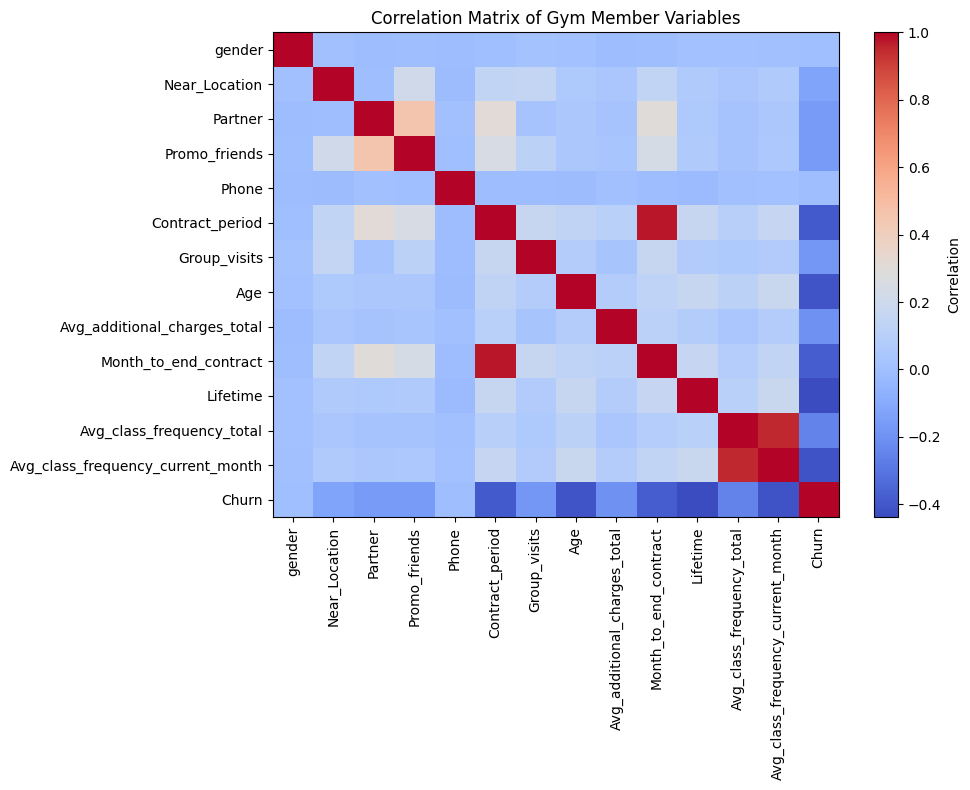

Correlation with Churn:
Churn                                1.000
gender                               0.001
Phone                               -0.001
Near_Location                       -0.128
Partner                             -0.158
Promo_friends                       -0.162
Group_visits                        -0.175
Avg_additional_charges_total        -0.199
Avg_class_frequency_total           -0.250
Month_to_end_contract               -0.381
Contract_period                     -0.390
Age                                 -0.405
Avg_class_frequency_current_month   -0.412
Lifetime                            -0.438
Name: Churn, dtype: float64


In [ ]:
# EDA 6: Correlation analysis

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Gym Member Variables")
plt.tight_layout()
plt.show()

print("Correlation with Churn:")
print(
    correlation_matrix["Churn"]
    .sort_values(ascending=False)
    .round(3)
)

### EDA 6 Interpretation — Correlation Analysis

The correlation analysis shows that several member characteristics have noticeable negative relationships with churn. The strongest relationships are observed for Lifetime (-0.438), Avg_class_frequency_current_month (-0.412), Age (-0.405), Contract_period (-0.390), and Month_to_end_contract (-0.381).

These negative correlations indicate that higher values of these variables are generally associated with lower churn in this dataset. In particular, member lifetime and recent class attendance show relatively strong relationships with churn, supporting the earlier EDA findings.

Group_visits (-0.175) and Avg_additional_charges_total (-0.199) show weaker negative relationships with churn. Gender (0.001) and Phone (-0.001) show almost no linear relationship with churn.

The correlation results provide an initial indication of potentially useful predictors. However, correlation alone does not establish causation, so the variables will be evaluated further using feature selection and machine-learning models.

In [ ]:
# EDA 7: Feature Engineering
# Create a feature showing the change in attendance frequency

df["frequency_change"] = (
    df["Avg_class_frequency_current_month"]
    - df["Avg_class_frequency_total"]
)

print("New feature created: frequency_change")
print(df[[
    "Avg_class_frequency_total",
    "Avg_class_frequency_current_month",
    "frequency_change",
    "Churn"
]].head(10))

New feature created: frequency_change
   Avg_class_frequency_total  Avg_class_frequency_current_month  \
0                   0.020398                           0.000000   
1                   1.922936                           1.910244   
2                   1.859098                           1.736502   
3                   3.205633                           3.357215   
4                   1.113884                           1.120078   
5                   2.623477                           2.637007   
6                   1.138941                           1.277242   
7                   1.213502                           1.049387   
8                   1.106239                           1.059333   
9                   1.810852                           1.951368   

   frequency_change  Churn  
0         -0.020398      0  
1         -0.012693      0  
2         -0.122596      0  
3          0.151582      0  
4          0.006194      0  
5          0.013530      0  
6          0.138300  

In [ ]:
# Analyze the new frequency_change feature

frequency_change_churn = df.groupby("Churn")["frequency_change"].mean()

print("Average frequency change by churn status:")
print(frequency_change_churn.round(3))

Average frequency change by churn status:
Churn
0    0.003
1   -0.430
Name: frequency_change, dtype: float64


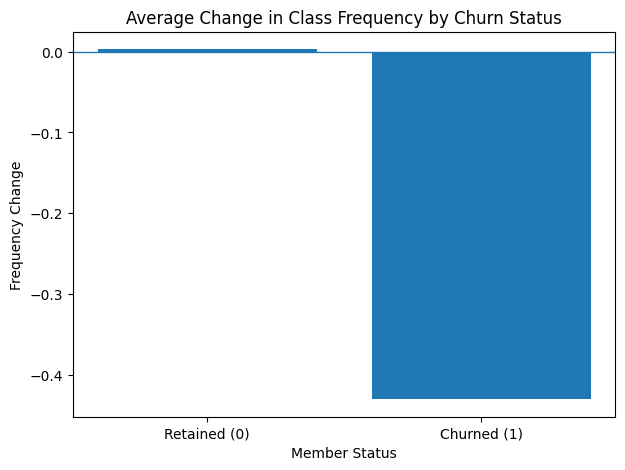

In [ ]:
# EDA 7: Frequency change by churn status

plt.figure(figsize=(7, 5))

plt.bar(
    ["Retained (0)", "Churned (1)"],
    frequency_change_churn.values
)

plt.axhline(0, linewidth=1)

plt.title("Average Change in Class Frequency by Churn Status")
plt.xlabel("Member Status")
plt.ylabel("Frequency Change")

plt.show()

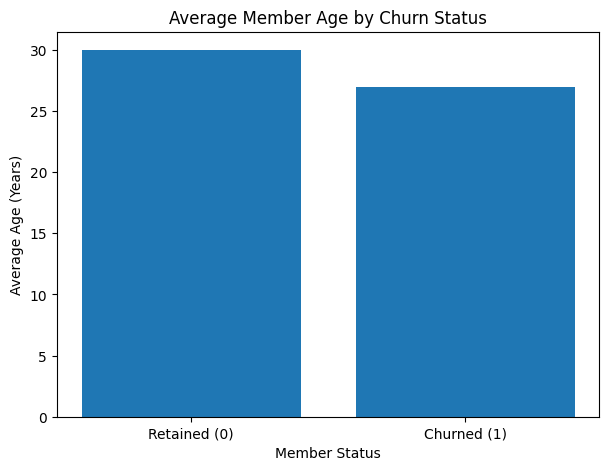

Average age by churn status:
Churn
0    29.98
1    26.99
Name: Age, dtype: float64


In [ ]:
# EDA 8: Average age by churn status

age_churn = df.groupby("Churn")["Age"].mean()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Retained (0)", "Churned (1)"],
    age_churn.values
)

plt.title("Average Member Age by Churn Status")
plt.xlabel("Member Status")
plt.ylabel("Average Age (Years)")

plt.show()

print("Average age by churn status:")
print(age_churn.round(2))

### EDA 8 Interpretation — Member Age and Churn

The analysis shows a difference in average age between retained and churned members. Retained members have an average age of approximately 29.98 years, while churned members have an average age of approximately 26.99 years.

This suggests that younger members in this dataset may have a higher likelihood of churn. Age may therefore provide useful information for predicting member churn.

From a business perspective, Healthletics could consider whether younger members require different onboarding, engagement, or retention strategies. However, age alone should not be used to determine whether a member will churn, and its effect should be evaluated together with other behavioral and membership variables.

## EDA Summary — Key Findings

The exploratory data analysis identified several patterns associated with member churn in the dataset.

Key findings include:

• Members with shorter contract periods have substantially higher churn rates than members with longer contracts.

• Churned members have substantially shorter average membership lifetimes than retained members.

• Churned members show lower recent class attendance, indicating that declining engagement may be an important warning signal.

• Members who do not participate in group visits have a higher churn rate than members who participate in group visits.

• Churned members are younger on average than retained members in this dataset.

• Correlation analysis indicates that Lifetime, recent class frequency, Age, Contract_period, and Month_to_end_contract have relatively strong negative relationships with churn.

• The engineered feature frequency_change shows a substantial difference between retained and churned members, suggesting that a decline in recent participation may provide additional predictive information.

These findings provide a basis for the next stage of the project: feature engineering, feature selection, dimensionality reduction, and machine-learning model development.

## 3.3 Feature Engineering

Feature engineering involves creating or transforming variables so that they provide useful information for machine-learning models.

Based on the EDA findings, a new behavioral feature called `frequency_change` was created.

`frequency_change` represents the difference between a member's current-month class attendance frequency and their historical average class attendance frequency.

A negative value indicates that recent attendance is lower than the member's historical attendance, while a positive value indicates increased recent participation.

This feature was created because the EDA suggested that changes in recent engagement may provide useful information for predicting member churn.

In [ ]:
# Create the frequency_change feature

df["frequency_change"] = (
    df["Avg_class_frequency_current_month"]
    - df["Avg_class_frequency_total"]
)

print("New feature created: frequency_change")

df[
    [
        "Avg_class_frequency_total",
        "Avg_class_frequency_current_month",
        "frequency_change",
        "Churn"
    ]
].head(10)

New feature created: frequency_change


,Avg_class_frequency_total,Avg_class_frequency_current_month,frequency_change,Churn
0,0.020398,0.000000,-0.020398,0
1,1.922936,1.910244,-0.012693,0
2,1.859098,1.736502,-0.122596,0
3,3.205633,3.357215,0.151582,0
4,1.113884,1.120078,0.006194,0
5,2.623477,2.637007,0.013530,0
6,1.138941,1.277242,0.138300,0
7,1.213502,1.049387,-0.164115,1
8,1.106239,1.059333,-0.046906,0
9,1.810852,1.951368,0.140516,0


In [ ]:
# Analyze frequency_change by churn status

frequency_change_churn = df.groupby("Churn")["frequency_change"].mean()

print("Average frequency change by churn status:")
print(frequency_change_churn.round(3))

Average frequency change by churn status:
Churn
0    0.003
1   -0.430
Name: frequency_change, dtype: float64


In [ ]:
from sklearn.feature_selection import mutual_info_classif

### 3.4 Feature Selection

Feature selection is the process of identifying which variables provide the most useful information for predicting member churn.

In this project, Mutual Information is used as a feature-selection method. It measures how much information each predictor provides about the churn outcome.

A higher Mutual Information score indicates that a feature contains more useful information about whether a member is likely to churn.

This analysis will help identify the most informative variables before developing the machine-learning models.

In [ ]:
# Calculate Mutual Information scores

X = df.drop("Churn", axis=1)
y = df["Churn"]

mi_scores = mutual_info_classif(X, y, random_state=42)

mi_results = pd.DataFrame({
    "Feature": X.columns,
    "Mutual_Information": mi_scores
}).sort_values(
    "Mutual_Information",
    ascending=False
)

print("Mutual Information scores:")
print(mi_results.round(4))

Mutual Information scores:
                              Feature  Mutual_Information
10                           Lifetime              0.2022
7                                 Age              0.1015
12  Avg_class_frequency_current_month              0.0983
5                     Contract_period              0.0944
9               Month_to_end_contract              0.0924
11          Avg_class_frequency_total              0.0587
8        Avg_additional_charges_total              0.0250
3                       Promo_friends              0.0222
1                       Near_Location              0.0175
6                        Group_visits              0.0146
2                             Partner              0.0080
4                               Phone              0.0054
0                              gender              0.0000


In [ ]:
# Feature Selection including engineered feature

X = df.drop("Churn", axis=1)
y = df["Churn"]

mi_scores = mutual_info_classif(X, y, random_state=42)

mi_results = pd.DataFrame({
    "Feature": X.columns,
    "Mutual_Information": mi_scores
}).sort_values(
    "Mutual_Information",
    ascending=False
)

print("Mutual Information scores including frequency_change:")
print(mi_results.round(4))

Mutual Information scores including frequency_change:
                              Feature  Mutual_Information
10                           Lifetime              0.2022
7                                 Age              0.1015
12  Avg_class_frequency_current_month              0.0983
5                     Contract_period              0.0944
9               Month_to_end_contract              0.0924
11          Avg_class_frequency_total              0.0587
8        Avg_additional_charges_total              0.0250
3                       Promo_friends              0.0222
1                       Near_Location              0.0175
6                        Group_visits              0.0146
2                             Partner              0.0080
4                               Phone              0.0054
0                              gender              0.0000


In [ ]:
print("frequency_change" in df.columns)
print(df.columns.tolist())

False
['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Contract_period', 'Group_visits', 'Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month', 'Churn']


In [ ]:
# Recreate the engineered frequency_change feature

df["frequency_change"] = (
    df["Avg_class_frequency_current_month"]
    - df["Avg_class_frequency_total"]
)

print("frequency_change created successfully.")
print(df[[
    "Avg_class_frequency_total",
    "Avg_class_frequency_current_month",
    "frequency_change"
]].head())

frequency_change created successfully.
   Avg_class_frequency_total  Avg_class_frequency_current_month  \
0                   0.020398                           0.000000   
1                   1.922936                           1.910244   
2                   1.859098                           1.736502   
3                   3.205633                           3.357215   
4                   1.113884                           1.120078   

   frequency_change  
0         -0.020398  
1         -0.012693  
2         -0.122596  
3          0.151582  
4          0.006194  


In [ ]:
# Recalculate Mutual Information including frequency_change

X = df.drop("Churn", axis=1)
y = df["Churn"]

mi_scores = mutual_info_classif(X, y, random_state=42)

mi_results = pd.DataFrame({
    "Feature": X.columns,
    "Mutual_Information": mi_scores
}).sort_values(
    "Mutual_Information",
    ascending=False
)

print("Final Mutual Information scores:")
print(mi_results.round(4))

Final Mutual Information scores:
                              Feature  Mutual_Information
13                   frequency_change              0.3423
10                           Lifetime              0.2087
5                     Contract_period              0.0969
12  Avg_class_frequency_current_month              0.0959
9               Month_to_end_contract              0.0951
7                                 Age              0.0945
11          Avg_class_frequency_total              0.0583
8        Avg_additional_charges_total              0.0250
3                       Promo_friends              0.0236
1                       Near_Location              0.0139
6                        Group_visits              0.0124
2                             Partner              0.0106
4                               Phone              0.0081
0                              gender              0.0000


In [ ]:
# 3.5 Feature Scaling

from sklearn.preprocessing import StandardScaler

# Separate predictors from the target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed successfully.")
print("Scaled data shape:", X_scaled.shape)

Feature scaling completed successfully.
Scaled data shape: (4000, 14)


In [ ]:
# 3.5 Principal Component Analysis (PCA)

from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("PCA completed successfully.")
print("Number of components:", X_pca.shape[1])

print("\nExplained variance by component:")
for i, variance in enumerate(explained_variance, start=1):
    print(f"Component {i}: {variance:.4f}")

print("\nCumulative explained variance:")
print(explained_variance.cumsum().round(4))

PCA completed successfully.
Number of components: 14

Explained variance by component:
Component 1: 0.2059
Component 2: 0.1343
Component 3: 0.0862
Component 4: 0.0791
Component 5: 0.0760
Component 6: 0.0719
Component 7: 0.0708
Component 8: 0.0671
Component 9: 0.0609
Component 10: 0.0592
Component 11: 0.0520
Component 12: 0.0349
Component 13: 0.0019
Component 14: 0.0000

Cumulative explained variance:
[0.2059 0.3402 0.4264 0.5055 0.5814 0.6534 0.7242 0.7912 0.8521 0.9113
 0.9632 0.9981 1.     1.    ]


In [ ]:
# Determine the number of components needed to retain at least 95% variance

import numpy as np

cumulative_variance = explained_variance.cumsum()

components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components needed to retain at least 95% variance:", components_95)
print("Cumulative explained variance:",
      cumulative_variance[components_95 - 1].round(4))

Components needed to retain at least 95% variance: 11
Cumulative explained variance: 0.9632


### PCA Interpretation

Principal Component Analysis (PCA) was applied to the standardized features to reduce dimensionality while preserving most of the information in the dataset.

The analysis showed that 11 principal components were sufficient to retain at least 95% of the total variance. These 11 components retained 96.32% of the cumulative explained variance.

This indicates that the dimensionality of the dataset can be reduced from 14 original features to 11 principal components while preserving most of the information. PCA will be evaluated as a dimensionality-reduction technique during the modelling stage."

## Step 3 Summary

The dataset was cleaned and examined through exploratory data analysis. No missing values or duplicate records were found. Key relationships between member characteristics, engagement behavior, and churn were identified.

A new feature called `frequency_change` was created to measure the change between a member's historical class frequency and their current-month class frequency. This feature provided strong information about churn behavior.

Mutual Information was used for feature selection. The most informative features included `frequency_change`, `Lifetime`, `Contract_period`, `Avg_class_frequency_current_month`, and `Month_to_end_contract`.

The features were standardized using StandardScaler before applying Principal Component Analysis (PCA). PCA showed that 11 components retained 96.32% of the total variance.

Overall, the preprocessing, exploratory analysis, feature engineering, feature selection, scaling, and dimensionality-reduction steps prepared the dataset for machine-learning model development in Step 4.

## 4.1 Preparing the Data for Modelling

The target variable is `Churn`, which represents whether a member was retained or churned.

The predictors will be separated from the target variable, and the dataset will then be divided into training and testing sets. Stratified splitting will be used to maintain a similar proportion of retained and churned members in both sets.

The training data will be used to develop the machine-learning models, while the testing data will be reserved for evaluating their performance on unseen observations.

In [ ]:
# Step 4.1 — Prepare data for machine-learning models

from sklearn.model_selection import train_test_split

# Recreate the engineered feature
df["frequency_change"] = (
    df["Avg_class_frequency_current_month"]
    - df["Avg_class_frequency_total"]
)

# Separate predictors from the target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data preparation completed successfully.")
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Data preparation completed successfully.
Training set: (3200, 14)
Testing set: (800, 14)

Training target distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [ ]:
# Step 4.2 — Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")
print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Feature scaling completed successfully.
Scaled training data: (3200, 14)
Scaled testing data: (800, 14)


In [ ]:
# Step 4.3 — Logistic Regression Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Create the model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = logistic_model.predict(X_test_scaled)
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_auc, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.9263
Precision: 0.8844
Recall   : 0.8302
F1 Score : 0.8564
ROC-AUC  : 0.9775


In [ ]:
# Step 4.4 — Decision Tree Model

from sklearn.tree import DecisionTreeClassifier

# Create the model
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train the model
decision_tree.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

# Evaluate the model
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Results")
print("--------------------")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))
print("ROC-AUC  :", round(dt_auc, 4))

Decision Tree Results
--------------------
Accuracy : 0.9463
Precision: 0.9519
Recall   : 0.8396
F1 Score : 0.8922
ROC-AUC  : 0.9701


In [ ]:
# Step 4.5 — Random Forest Model

from sklearn.ensemble import RandomForestClassifier

# Create the model
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the model
random_forest.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

# Evaluate the model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

Random Forest Results
---------------------
Accuracy : 0.965
Precision: 0.96
Recall   : 0.9057
F1 Score : 0.932
ROC-AUC  : 0.9879


In [ ]:
# Step 4.6 — Model Comparison

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ],
    "ROC-AUC": [
        lr_auc,
        dt_auc,
        rf_auc
    ]
})

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9262,0.8844,0.8302,0.8564,0.9775
1,Decision Tree,0.9462,0.9519,0.8396,0.8922,0.9701
2,Random Forest,0.9650,0.9600,0.9057,0.9320,0.9879


In [ ]:
# Step 4.7 — Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
}).sort_values("Importance", ascending=False)

print("Random Forest Feature Importance:")
display(feature_importance.round(4))

Random Forest Feature Importance:


,Feature,Importance
13,frequency_change,0.3976
10,Lifetime,0.1946
12,Avg_class_frequency_current_month,0.0873
7,Age,0.0795
11,Avg_class_frequency_total,0.0624
9,Month_to_end_contract,0.0562
8,Avg_additional_charges_total,0.0461
5,Contract_period,0.0388
6,Group_visits,0.0093
2,Partner,0.0068


In [ ]:
import matplotlib.pyplot as plt

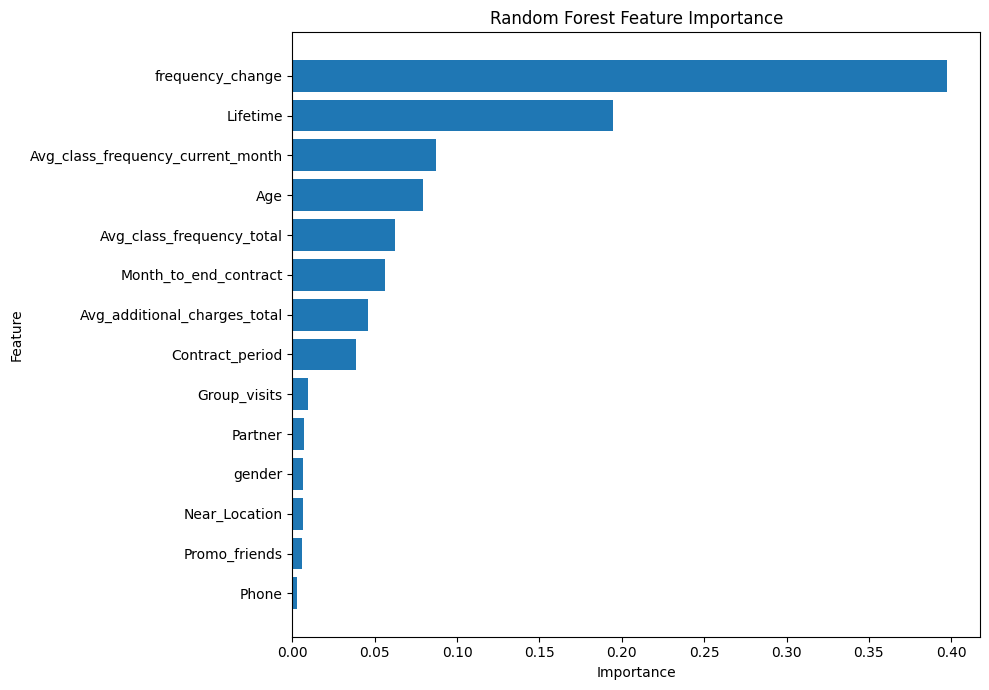

In [ ]:
# Step 4.8 — Feature Importance Visualization

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Feature Importance Interpretation

The Random Forest feature-importance analysis shows that frequency_change is the most important predictor of gym member churn, with an importance value of approximately 0.3976. This is followed by Lifetime at 0.1946 and Avg_class_frequency_current_month at 0.0873.

The results suggest that changes in a member's recent class participation and the length of time they have been members are important signals associated with churn prediction.

Other variables, including Age, historical class frequency, Month_to_end_contract, additional charges, and Contract_period, also contribute to the model but have lower relative importance.

These results provide useful business insight for Healthletics because changes in member engagement may serve as an early warning signal for potential churn. However, feature importance indicates the contribution of variables to the model and does not by itself establish causation.

In [ ]:
# Step 4.9 – Model Comparison

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ],
    "ROC-AUC": [
        lr_auc,
        dt_auc,
        rf_auc
    ]
})

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9262,0.8844,0.8302,0.8564,0.9775
1,Decision Tree,0.9462,0.9519,0.8396,0.8922,0.9701
2,Random Forest,0.9650,0.9600,0.9057,0.9320,0.9879



   ### Model Comparison Interpretation

Three classification models were evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

Logistic Regression achieved an ROC-AUC of 0.9775, while Decision Tree achieved 0.9701. Random Forest achieved the highest ROC-AUC of 0.9879 and also produced the highest Recall and F1 Score among the three models.

The results indicate that Random Forest provided the strongest overall performance on the test dataset. Its Recall of 0.9057 is particularly relevant to the business problem because identifying members who are likely to churn is an important objective of the Healthletics retention system.

Therefore, Random Forest will be carried forward for further evaluation and interpretation. The model's performance should still be assessed for potential overfitting, data leakage, and fairness considerations before considering it suitable for practical use.

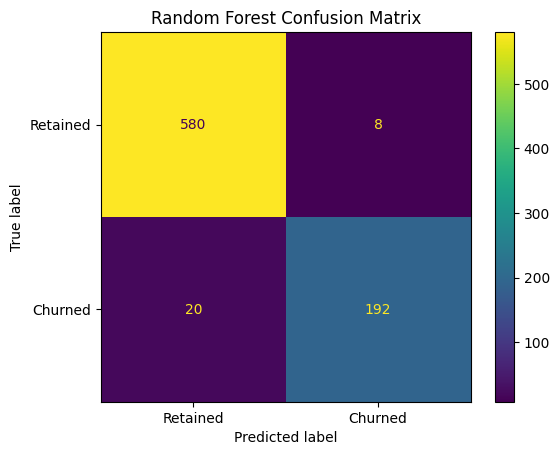

In [ ]:
# Step 4.10 – Random Forest Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Retained", "Churned"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

The Random Forest confusion matrix shows the classification results on the test dataset.

The model correctly classified 580 retained members and 192 churned members. It incorrectly classified 8 retained members as churned and 20 churned members as retained.

The 20 churned members incorrectly classified as retained represent false negatives. In the Healthletics context, these are members who may be at risk of churn but were not identified by the model. Reducing false negatives is therefore important because missed at-risk members may not receive timely retention interventions.

The confusion matrix supports the previously observed Recall of 0.9057 for the churn class and provides a clearer view of the model's classification performance.

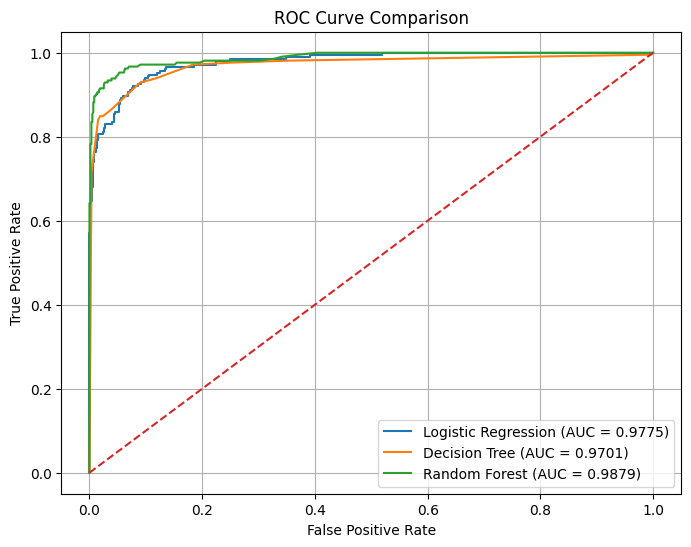

In [ ]:
# Step 4.11 – ROC Curve Comparison

from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {lr_auc:.4f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {dt_auc:.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

ROC Curve Interpretation

The ROC curve comparison shows that all three classification models achieved strong discrimination between retained and churned gym members. Logistic Regression achieved an AUC of 0.9775, Decision Tree achieved 0.9701, and Random Forest achieved 0.9879.

The Random Forest model produced the highest AUC among the three models, indicating strong ability to distinguish between members who churn and those who remain. This result is consistent with the model comparison and supports carrying Random Forest forward for further evaluation.

However, ROC-AUC is evaluated on the test dataset and does not by itself guarantee performance on future Healthletics members. Further validation, including overfitting checks and bias/fairness analysis, is therefore necessary.

Don’t run anything for this part because it’s a Text cell.

## Step 4.13 — Final Model Selection

Based on the evaluation results, Random Forest will be carried forward as the selected model for the next stages of the capstone.

The Random Forest model achieved an Accuracy of 0.9650, Precision of 0.9600, Recall of 0.9057, F1 Score of 0.9320, and ROC-AUC of 0.9879 on the test dataset.

The model will be used for further interpretation, including feature analysis, model explainability, and ethical AI and bias considerations. These additional analyses are important before considering how the model could eventually be applied to the Healthletics business context.

The selected model should be considered a proof of concept because the analysis uses a public gym dataset rather than actual Healthletics member data.

In [ ]:
import numpy as np

In [ ]:
# Step 4.14 — Cross-Validation for Random Forest

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    random_forest,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Random Forest 5-Fold Cross-Validation")
print("------------------------------------")
print("AUC scores:", np.round(cv_scores, 4))
print("Mean ROC-AUC:", round(cv_scores.mean(), 4))
print("Standard Deviation:", round(cv_scores.std(), 4))

Random Forest 5-Fold Cross-Validation
------------------------------------
AUC scores: [0.9825 0.9851 0.9911 0.9909 0.9902]
Mean ROC-AUC: 0.988
Standard Deviation: 0.0035


## Cross-Validation Interpretation

The Random Forest model was evaluated using 5-fold cross-validation to assess the consistency of its performance across different subsets of the training data.

The five ROC-AUC scores ranged from 0.9825 to 0.9911, with a mean ROC-AUC of 0.9880 and a standard deviation of 0.0035.

The small standard deviation indicates that the model's performance was relatively stable across the five validation folds. This provides additional evidence that the Random Forest model is not highly dependent on a single train-test split.

However, cross-validation does not eliminate the possibility of overfitting or guarantee performance on future Healthletics data. The model will therefore undergo further analysis, including explainability, limitations, and ethical AI considerations.

In [ ]:
# Step 4.15 — Permutation Importance

from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    random_forest,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)

permutation_results = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
}).sort_values("Importance", ascending=False)

print("Permutation Importance")
display(permutation_results.round(4))

Permutation Importance


,Feature,Importance
13,frequency_change,0.1138
10,Lifetime,0.0385
12,Avg_class_frequency_current_month,0.0064
7,Age,0.0048
9,Month_to_end_contract,0.0035
11,Avg_class_frequency_total,0.0029
5,Contract_period,0.0022
8,Avg_additional_charges_total,0.0020
6,Group_visits,0.0014
4,Phone,0.0000


## Permutation Importance Interpretation

Permutation importance was used to examine how much the Random Forest model depends on each feature when predicting gym member churn.

The results show that frequency_change had the largest permutation importance at 0.1138, followed by Lifetime at 0.0385. Avg_class_frequency_current_month and Age had substantially smaller values of 0.0064 and 0.0048, respectively.

The result reinforces the earlier feature-importance analysis, where frequency_change and Lifetime were also among the most influential predictors. This suggests that changes in recent member activity and the length of the member's relationship with the gym provide important information for the model's churn predictions.

The results should not be interpreted as proof that these variables cause churn. Permutation importance measures the contribution of features to model performance and can be affected by relationships between correlated variables.

<Figure size 900x600 with 0 Axes>

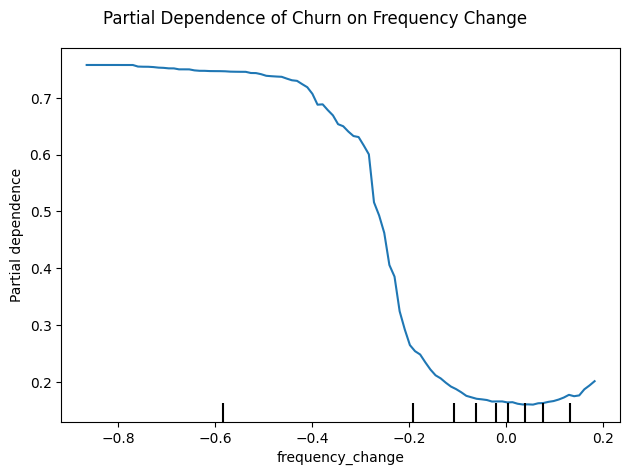

In [ ]:

# Step 4.15 — Partial Dependence Analysis

from sklearn.inspection import PartialDependenceDisplay

plt.figure(figsize=(9, 6))

PartialDependenceDisplay.from_estimator(
    random_forest,
    X_train,
    ["frequency_change"]
)

plt.suptitle("Partial Dependence of Churn on Frequency Change")
plt.tight_layout()
plt.show()

### Partial Dependence Interpretation

The partial dependence analysis examines the relationship between frequency_change and the Random Forest model's predicted churn probability.

The graph shows that predicted churn probability is substantially higher when frequency_change is strongly negative, indicating a decline in recent class participation compared with a member's historical activity. As frequency_change moves closer to zero, the predicted churn probability decreases substantially.

This finding is consistent with the feature-importance and permutation-importance analyses, which identified frequency_change as an important predictor of churn.

From a business perspective, a decline in recent member activity may serve as an early warning signal for potential churn. Healthletics could use this type of engagement change as one input for identifying members who may benefit from timely retention interventions.

However, partial dependence describes the model's learned relationship and does not establish that reduced attendance directly causes churn. The relationship may also be influenced by other correlated variables and patterns in the dataset.

# Step 5 — Ethical AI and Bias Auditing

## 5.1 Ethical AI Considerations

The Healthletics churn prediction system is intended to support member-retention decisions by identifying patterns associated with potential churn. Because predictions could influence how members are approached for retention interventions, ethical considerations must be addressed.

The model should be used as a decision-support tool rather than as the sole basis for decisions about individual members. Predictions should be reviewed together with relevant business context, and members should not be treated unfairly based solely on demographic characteristics.

The analysis should also consider data quality, potential bias, class imbalance, feature leakage, and the limitations of using a public dataset as a proxy for Healthletics members.

The current analysis is a proof of concept. Before deployment at Healthletics, the model would need to be retrained and validated using appropriately collected and anonymized Healthletics data.

In [ ]:
# Step 5.2 — Churn Rate by Gender

gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

gender_churn.columns = ["Retained (%)", "Churned (%)"]

print("Churn Rate by Gender")
display(gender_churn.round(2))

Churn Rate by Gender


,Retained (%),Churned (%)
gender,,
0,73.51,26.49
1,73.44,26.56


In [ ]:
# Step 5.3 — Churn Rate by Age Group

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[17, 24, 29, 34, 41],
    labels=["18–24", "25–29", "30–34", "35–41"]
)

age_churn = pd.crosstab(
    df["Age_Group"],
    df["Churn"],
    normalize="index"
) * 100

age_churn.columns = ["Retained (%)", "Churned (%)"]

print("Churn Rate by Age Group")
display(age_churn.round(2))

Churn Rate by Age Group


,Retained (%),Churned (%)
Age_Group,,
18–24,33.77,66.23
25–29,63.98,36.02
30–34,88.23,11.77
35–41,97.88,2.12


In [ ]:
# Step 5.4 — Random Forest Performance by Age Group

from sklearn.metrics import accuracy_score, recall_score, precision_score

age_groups = df.loc[X_test.index, "Age_Group"]

fairness_results = []

for group in age_groups.dropna().unique():
    mask = age_groups == group

    y_true_group = y_test[mask]
    y_pred_group = y_pred_rf[mask]

    fairness_results.append({
        "Age Group": group,
        "Members": mask.sum(),
        "Accuracy": accuracy_score(y_true_group, y_pred_group),
        "Precision": precision_score(y_true_group, y_pred_group, zero_division=0),
        "Recall": recall_score(y_true_group, y_pred_group, zero_division=0)
    })

fairness_results = pd.DataFrame(fairness_results)

print("Random Forest Performance by Age Group")
display(fairness_results.round(4))

Random Forest Performance by Age Group


,Age Group,Members,Accuracy,Precision,Recall
0,25–29,377,0.9655,0.9606,0.9385
1,30–34,328,0.9543,0.9091,0.7143
2,35–41,36,1.0000,0.0000,0.0000
3,18–24,59,1.0000,1.0000,1.0000


### Bias Audit Interpretation by Age Group

The Random Forest model was evaluated separately across age groups to examine whether predictive performance differs between groups.

The results show that model performance is not identical across all age groups. The 25–29 group had high precision and recall, while the 30–34 group had lower recall of 0.7143. The 35–41 group had an accuracy of 1.0000 but a recall of 0.0000.

The results for the 35–41 group should be interpreted cautiously because only 36 members were included in the test subset and the observed churn rate for this age group was very low. With very few churn cases, accuracy and recall can become unstable and may not provide a reliable representation of future performance.

These differences do not by themselves establish that the model is biased. They indicate that additional fairness analysis is needed, particularly for groups with small sample sizes. Before deployment, Healthletics should evaluate model performance using a larger and more representative dataset and monitor recall, precision, and error rates across relevant member groups.

The model should not be used to automatically deny services or apply negative actions to members based on age or other demographic characteristics.

In [ ]:
# Step 5.5 — Prediction Rate by Age Group

prediction_rate = []

for group in age_groups.dropna().unique():
    mask = age_groups == group

    predicted_churn_rate = y_pred_rf[mask].mean()

    prediction_rate.append({
        "Age Group": group,
        "Members": mask.sum(),
        "Predicted Churn Rate (%)": predicted_churn_rate * 100
    })

prediction_rate = pd.DataFrame(prediction_rate)

print("Predicted Churn Rate by Age Group")
display(prediction_rate.round(2))

Predicted Churn Rate by Age Group


,Age Group,Members,Predicted Churn Rate (%)
0,25–29,377,33.69
1,30–34,328,10.06
2,35–41,36,0.00
3,18–24,59,67.80


The predicted churn rate varies across the age groups. The Random Forest model predicted churn for 67.80% of members aged 18–24, 33.69% of members aged 25–29, 10.06% of members aged 30–34, and 0.00% of members aged 35–41.

These differences indicate that the model’s predictions are not distributed equally across age groups. However, prediction-rate differences alone do not establish that the model is unfair, because the underlying dataset also shows substantial differences in observed churn rates between age groups.

The 35–41 result should be interpreted particularly cautiously because only 36 members were included in the test set. Small group sizes can produce unstable estimates.

For a real Healthletics deployment, fairness should be evaluated using a larger and more representative dataset, with additional metrics and monitoring across relevant member groups. Age should not be used as the sole basis for negative actions toward members.

The bias audit examined model performance across gender and age groups. Gender-level churn rates were very similar in the dataset, while larger differences were observed across age groups in both actual and predicted churn rates.

The Random Forest model also showed different levels of precision and recall across age groups. These differences should not automatically be interpreted as evidence of unfairness because they may reflect underlying differences in the dataset and differences in group sample sizes.

In particular, the 35–41 age group had only 36 members in the test set, making its performance measures less reliable. This highlights the importance of using sufficiently large and representative data when evaluating fairness.

For future Healthletics deployment, the model should be retrained using anonymized Healthletics data and regularly audited for differences in performance across relevant member groups. Predictions should be used as decision-support information rather than as the sole basis for decisions about individual members.

Overall, the bias audit identifies areas that require further monitoring and validation before deployment. It also demonstrates that ethical AI requires consideration of data quality, representation, model performance, privacy, and potential unintended impacts.

# Step 6 — Final Presentation & Communication

The results of the Healthletics churn prediction project will be communicated to two audiences: a technical audience and a business audience.

The technical presentation will explain the machine learning workflow, including the business problem, dataset, preprocessing, exploratory data analysis, feature engineering, model development, evaluation, explainability, and ethical AI considerations.

The business-facing presentation will translate the technical findings into practical Healthletics insights. It will focus on identifying members who may be at risk of churn, understanding engagement patterns, supporting timely retention actions, and considering how the model could contribute to a future member management and retention system.

The current project is a proof of concept based on a public gym dataset. Before practical deployment, the model would need to be retrained, validated, and monitored using appropriately collected and anonymized Healthletics data.

### 6.1 Technical Presentation

The technical presentation will communicate the complete machine learning workflow used in the Healthletics member churn prediction project.

The presentation will cover:

1. Business problem and project objectives
2. Dataset overview and data quality assessment
3. Exploratory data analysis and key findings
4. Data preprocessing and feature engineering
5. Feature selection and dimensionality reduction
6. Machine learning model development
7. Model evaluation and comparison
8. Model explainability and important predictors
9. Bias, fairness, limitations, and ethical AI considerations
10. Conclusions and recommendations for future Healthletics deployment

The technical presentation will be based on the results produced in the Jupyter/Google Colab notebook. Numerical results, charts, and model performance metrics will be taken directly from the analysis to maintain consistency and reproducibility.

### 6.2 Business-Facing Presentation

The business-facing presentation will translate the machine learning findings into practical insights for Healthletics management.

The presentation will focus on:

1. Why member retention and churn matter to the business
2. Key patterns associated with member churn
3. Member characteristics and engagement behaviors associated with higher churn risk
4. How a churn prediction system could support timely retention actions
5. How Healthletics could use member activity and membership data for better decision-making
6. Potential business benefits, including improved retention and more targeted member engagement
7. Limitations of the current proof-of-concept model
8. Data privacy, fairness, and responsible AI considerations
9. Requirements for future validation using real and anonymized Healthletics data
10. Future integration into a Healthletics member management and analytics system

The business presentation will avoid presenting model predictions as certain outcomes. Predictions should be treated as decision-support information that can help staff identify members who may need attention.

### 6.3 Presentation Deliverables

Two presentation decks will be prepared as required by the capstone:

**Technical Presentation**
- Audience: Technical and academic audience
- Format: Jupyter slides or LaTeX Beamer
- Focus: Machine learning workflow, methodology, results, evaluation, explainability, and ethical AI

**Business-Facing Presentation**
- Audience: Healthletics management and business stakeholders
- Format: PowerPoint or Canva
- Focus: Business problem, key findings, member retention insights, practical applications, risks, and future strategy

Each presentation will contain approximately 8–12 concise slides and will use results directly from the capstone analysis.

### Step 7 — GitHub Profile & Upload

The Healthletics capstone project will be organized as a reproducible machine learning project suitable for GitHub.

The repository will contain:

1. README.md
   - Project title
   - Business problem
   - Project objectives
   - Dataset description
   - Methodology
   - Key findings
   - Model evaluation
   - Ethical AI considerations
   - Limitations
   - Future Healthletics application

2. notebooks/
   - Healthletics_Capstone.ipynb

3. data/
   - Public dataset used for the proof-of-concept analysis

4. models/
   - Saved trained model files, where appropriate

5. reports/
   - Final capstone report and supporting documentation

6. presentations/
   - Technical presentation
   - Business-facing presentation

7. requirements.txt
   - Python libraries and versions required to reproduce the analysis

The repository will be structured to support reproducibility, transparency, and future development. The public dataset will remain clearly identified as a proof-of-concept dataset and will not be presented as actual Healthletics member data.